### Train transformer

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from transformers import CLIPTextModel, CLIPTokenizer
from diffusers.models import AutoencoderKLFlux2
from diffusers import FlowMatchEulerDiscreteScheduler
import torch
import torch.nn as nn
import torch.nn.functional as F
import json

from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

device = "cuda"
plt.style.use("dark_background")

In [2]:
text_encoder = CLIPTextModel.from_pretrained(
    "../../stable-diffusion-xl-base-1.0/text_encoder"
).to("cuda", torch.float32)
tokenizer = CLIPTokenizer.from_pretrained(
    "../../stable-diffusion-xl-base-1.0/tokenizer"
)
vae = AutoencoderKLFlux2.from_pretrained("../../FLUX.2-klein-4B/vae", device=device).to(
    device
)
scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained(
    "../../FLUX.2-klein-4B/scheduler", device=device
)

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

In [3]:
def encode_text_batch(text_batch):
    inputs = tokenizer(
        text_batch,
        padding="max_length",
        truncation=True,
        max_length=tokenizer.model_max_length,
        return_tensors="pt",
    ).to("cuda")

    with torch.no_grad():
        embed = text_encoder(
            inputs.input_ids, output_hidden_states=True, return_dict=True
        )
        text_embeds = embed.hidden_states[-2]

    return text_embeds


latents_bn_mean = vae.bn.running_mean.view(1, -1, 1, 1).to(device)
latents_bn_std = torch.sqrt(
    vae.bn.running_var.view(1, -1, 1, 1) + vae.config.batch_norm_eps
).to(device)


def prepare_latent_ids(
    latents: torch.Tensor,  # (B, C, H, W)
):
    r"""
    Generates 4D position coordinates (T, H, W, L) for latent tensors.

    Args:
        latents (torch.Tensor):
            Latent tensor of shape (B, C, H, W)

    Returns:
        torch.Tensor:
            Position IDs tensor of shape (B, H*W, 4) All batches share the same coordinate structure: T=0,
            H=[0..H-1], W=[0..W-1], L=0
    """

    batch_size, _, height, width = latents.shape

    t = torch.arange(1)  # [0] - time dimension
    h = torch.arange(height)
    w = torch.arange(width)
    l = torch.arange(1)  # [0] - layer dimension

    # Create position IDs: (H*W, 4)
    latent_ids = torch.cartesian_prod(t, h, w, l)

    # Expand to batch: (B, H*W, 4)
    latent_ids = latent_ids.unsqueeze(0).expand(batch_size, -1, -1)

    return latent_ids


def prepare_text_ids(
    x: torch.Tensor,  # (B, L, D) or (L, D)
    t_coord: torch.Tensor | None = None,
):
    B, L, _ = x.shape
    out_ids = []

    for i in range(B):
        t = torch.arange(1) if t_coord is None else t_coord[i]
        h = torch.arange(1)
        w = torch.arange(1)
        l = torch.arange(L)

        coords = torch.cartesian_prod(t, h, w, l)
        out_ids.append(coords)

    return torch.stack(out_ids)


def patchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.view(
        batch_size, num_channels_latents, height // 2, 2, width // 2, 2
    )
    latents = latents.permute(0, 1, 3, 5, 2, 4)
    latents = latents.reshape(
        batch_size, num_channels_latents * 4, height // 2, width // 2
    )
    return latents


def unpatchify_latents(latents):
    batch_size, num_channels_latents, height, width = latents.shape
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), 2, 2, height, width
    )
    latents = latents.permute(0, 1, 4, 2, 5, 3)
    latents = latents.reshape(
        batch_size, num_channels_latents // (2 * 2), height * 2, width * 2
    )
    return latents


def pack_latents(latents):
    """
    pack latents: (batch_size, num_channels, height, width) -> (batch_size, height * width, num_channels)
    """

    batch_size, num_channels, height, width = latents.shape
    latents = latents.reshape(batch_size, num_channels, height * width).permute(0, 2, 1)

    return latents


def unpack_latents_with_ids(
    x: torch.Tensor,
    x_ids: torch.Tensor,
    height: int | None = None,
    width: int | None = None,
) -> list[torch.Tensor]:
    """
    using position ids to scatter tokens into place
    """
    x_list = []
    for data, pos in zip(x, x_ids):
        _, ch = data.shape  # noqa: F841
        h_ids = pos[:, 1].to(torch.int64)
        w_ids = pos[:, 2].to(torch.int64)

        # Use provided height/width to avoid DtoH sync from torch.max().item()
        h = height if height is not None else torch.max(h_ids) + 1
        w = width if width is not None else torch.max(w_ids) + 1

        flat_ids = h_ids * w + w_ids

        out = torch.zeros((h * w, ch), device=data.device, dtype=data.dtype)
        out.scatter_(0, flat_ids.unsqueeze(1).expand(-1, ch), data)

        # reshape from (H * W, C) to (H, W, C) and permute to (C, H, W)

        out = out.view(h, w, ch).permute(2, 0, 1)
        x_list.append(out)

    return torch.stack(x_list, dim=0)

In [4]:
embeds = encode_text_batch(["A cat on the grass", "A man"])
print(embeds.shape)
text_ids = prepare_text_ids(embeds)
print(text_ids.shape)

torch.Size([2, 77, 768])
torch.Size([2, 77, 4])


In [5]:
train_batch_size = 128

In [6]:
class LatentsAndTextsDataset(Dataset):
    def __init__(self):
        self.latents = torch.load("../../precomputes/latents_256x256.pt")
        self.texts = []

        with open("../../coco2017/annotations/captions_train2017.json") as f:
            data = json.load(f)

        for annotation in data["annotations"]:
            caption = annotation["caption"]
            self.texts.append(caption)

    def __len__(self):
        assert len(self.latents) == len(self.texts)
        return len(self.latents)

    def __getitem__(self, idx):
        return self.latents[idx], self.texts[idx]

In [7]:
dataset = LatentsAndTextsDataset()

In [8]:
train_loader = DataLoader(dataset, batch_size=train_batch_size, shuffle=True)

torch.Size([128, 32, 32, 32]) cpu torch.float16 tensor(-12.6797, dtype=torch.float16) tensor(12.4141, dtype=torch.float16)


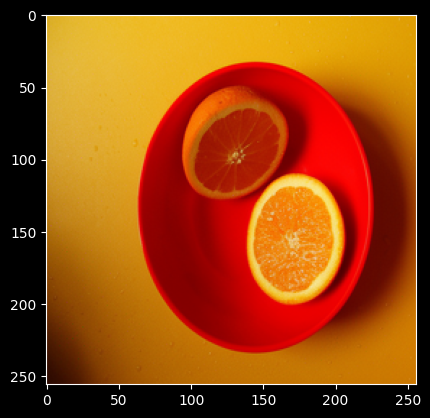

A couple of orange halves in a red bowl with an orange background.


In [9]:
latents, texts = next(iter(train_loader))
print(latents.shape, latents.device, latents.dtype, latents.min(), latents.max())

with torch.no_grad():
    # latents = patchify_latents(latents)
    # latents = latents * latents_bn_std.cpu()
    # latents = latents + latents_bn_mean.cpu()
    # latents = unpatchify_latents(latents)
    reconstructed = (vae.decode(latents[:1].cuda().float()).sample + 1.0) / 2.0

reconstructed = reconstructed.squeeze(0).permute((1, 2, 0)).cpu().numpy()
reconstructed = np.clip(reconstructed, 0, 1)

plt.imshow(reconstructed)
plt.show()

print(texts[0])

In [10]:
from diffusers.models.embeddings import (
    TimestepEmbedding,
    Timesteps,
    apply_rotary_emb,
    get_1d_rotary_pos_embed,
)


class PosEmbed(nn.Module):
    def __init__(self, theta: int, axes_dim: list[int]):
        super().__init__()
        self.theta = theta
        self.axes_dim = axes_dim

    def forward(self, ids: torch.Tensor) -> torch.Tensor:
        if ids.ndim == 3:
            ids = ids[0]

        cos_out = []
        sin_out = []
        pos = ids.float()
        freqs_dtype = torch.float64
        for i in range(len(self.axes_dim)):
            cos, sin = get_1d_rotary_pos_embed(
                self.axes_dim[i],
                pos[..., i],
                theta=self.theta,
                repeat_interleave_real=True,
                use_real=True,
                freqs_dtype=freqs_dtype,
            )
            cos_out.append(cos)
            sin_out.append(sin)
        freqs_cos = torch.cat(cos_out, dim=-1).to(ids.device)
        freqs_sin = torch.cat(sin_out, dim=-1).to(ids.device)
        return freqs_cos, freqs_sin


class AttentionBlock(nn.Module):
    def __init__(self, channels, num_heads=8, head_dim=64):
        super().__init__()
        self.norm1 = nn.RMSNorm(channels)

        self.to_q = nn.Linear(channels, num_heads * head_dim)
        self.to_k = nn.Linear(channels, num_heads * head_dim)
        self.to_v = nn.Linear(channels, num_heads * head_dim)
        self.to_out = nn.Linear(num_heads * head_dim, channels)

        self.q_norm = nn.RMSNorm(head_dim)
        self.k_norm = nn.RMSNorm(head_dim)

        self.norm2 = nn.RMSNorm(channels)
        self.ff = nn.Sequential(
            nn.Linear(channels, channels * 4),
            nn.GELU(),
            nn.Linear(channels * 4, channels),
        )

        self.num_heads = num_heads
        self.head_dim = head_dim

    def forward(self, x, rotary_emb):
        b, l, _ = x.shape
        h = self.norm1(x)

        q = self.to_q(h)
        k = self.to_k(h)
        v = self.to_v(h)

        q = q.view(b, l, self.num_heads, self.head_dim).transpose(1, 2)
        k = k.view(b, l, self.num_heads, self.head_dim).transpose(1, 2)
        v = v.view(b, l, self.num_heads, self.head_dim).transpose(1, 2)

        q = self.q_norm(q)
        k = self.k_norm(k)

        q = apply_rotary_emb(q, rotary_emb, sequence_dim=2)
        k = apply_rotary_emb(k, rotary_emb, sequence_dim=2)

        h = F.scaled_dot_product_attention(q, k, v)
        h = h.transpose(1, 2).reshape(b, l, self.num_heads * self.head_dim)
        h = self.to_out(h)

        x = x + h
        x = x + self.ff(self.norm2(x))
        return x


class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int = 128, max_period: int = 10000):
        super().__init__()
        self.dim = dim
        self.max_period = max_period

    def forward(self, timesteps: torch.Tensor) -> torch.Tensor:
        half = self.dim // 2
        timesteps = timesteps.float()

        freqs = torch.exp(
            -torch.log(torch.tensor(float(self.max_period), device=timesteps.device))
            * torch.arange(half, device=timesteps.device, dtype=timesteps.dtype)
            / half
        )
        args = timesteps[:, None] * freqs[None]
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

        if self.dim % 2 == 1:
            emb = F.pad(emb, (0, 1))

        return emb


class Modulation(nn.Module):
    def __init__(self, dim, time_embed_dim: int = 128):
        super().__init__()
        self.time_embed = SinusoidalTimeEmbedding()
        self.ff = nn.Sequential(
            nn.Linear(time_embed_dim, dim * 2),
            nn.SiLU(),
            nn.Linear(dim * 2, dim * 2),
        )

    def forward(self, timestep):
        embed = self.time_embed(timestep)
        mod = self.ff(embed)
        scale, shift = torch.chunk(mod, 2, dim=-1)
        return scale[:, None, :], shift[:, None, :]


class Transformer(nn.Module):
    def __init__(
        self,
        sample_dim: int = 128,
        base_dim: int = 512,
        text_dim: int = 768,
        num_heads: int = 8,
        head_dim: int = 64,
        num_blocks: int = 16,
    ):
        super().__init__()

        self.in_proj = nn.Linear(sample_dim, base_dim)
        self.out_proj = nn.Linear(base_dim, sample_dim)
        self.text_proj = nn.Linear(text_dim, base_dim)

        self.modulation = Modulation(base_dim)
        self.pos_embed = PosEmbed(theta=2000, axes_dim=(16, 16, 16, 16))

        self.blocks = nn.ModuleList(
            [
                AttentionBlock(
                    channels=base_dim, num_heads=num_heads, head_dim=head_dim
                )
                for _ in range(num_blocks)
            ]
        )

    def forward(self, hidden_states, encoder_hidden_states, timestep, img_ids, txt_ids):
        """
        hidden_states: [batch, seq_len, sample_dim]
        encoder_hidden_states: [batch, text_seq_len, text_dim]
        timestep: [batch,]

        return:
        hidden_states: [batch, seq_len, sample_dim]
        """
        text_seq_len = encoder_hidden_states.shape[1]
        seq_len = hidden_states.shape[1]

        image_rotary_emb = self.pos_embed(img_ids)
        text_rotary_emb = self.pos_embed(txt_ids)

        concat_rotary_emb = (
            torch.cat([text_rotary_emb[0], image_rotary_emb[0]], dim=0),
            torch.cat([text_rotary_emb[1], image_rotary_emb[1]], dim=0),
        )

        encoder_hidden_states = self.text_proj(encoder_hidden_states)
        hidden_states = self.in_proj(hidden_states)

        hidden_states = torch.cat([encoder_hidden_states, hidden_states], dim=1)

        scale, shift = self.modulation(timestep)

        for block in self.blocks:
            hidden_states = block(hidden_states, concat_rotary_emb)
            hidden_states = hidden_states * (1 + scale) + shift

        hidden_states = hidden_states[:, text_seq_len:, :]

        hidden_states = self.out_proj(hidden_states)

        return hidden_states

In [11]:
transformer = Transformer()
transformer = transformer.to(device)

optimizer = torch.optim.AdamW(transformer.parameters(), lr=1e-4)
num_train_timesteps = 1000

total_params = sum(p.numel() for p in transformer.parameters())
print("Total params:", total_params / 1000000, "M")

Total params: 52.130944 M


In [14]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import torch
from IPython.display import clear_output


def get_next_sample_index(save_directory):
    """
    Finds the next available integer index for sample files
    of the form sample_<index>.png or sample_epochX_<index>.png.
    """
    pattern = re.compile(r"sample_(?:epoch\d+_)?(\d+)\.png")
    max_index = -1

    for fname in os.listdir(save_directory):
        match = pattern.match(fname)
        if match:
            max_index = max(max_index, int(match.group(1)))

    return max_index + 1


def generate_test_sample(
    save_directory="../../samples/transformer/t-1",
    epoch_number=None,
    prompt="There are two black dogs on the field of green grass.",
    cfg=5.0,
    save=True,
):
    os.makedirs(save_directory, exist_ok=True)

    sample_index = get_next_sample_index(save_directory)

    if epoch_number is not None:
        filename = f"sample_epoch{epoch_number}_{sample_index}.png"
    else:
        filename = f"sample_{sample_index}.png"

    save_path = os.path.join(save_directory, filename)

    text_embeds = encode_text_batch([prompt])
    negative_text_embeds = torch.zeros_like(text_embeds)
    txt_ids = prepare_text_ids(text_embeds).to(device)

    scheduler.set_timesteps(50, mu=1.0)
    latents = torch.normal(0, 1, (1, 32, 32, 32), dtype=torch.float32, device="cuda")
    latents = patchify_latents(latents)

    latent_ids = prepare_latent_ids(latents).to(device)
    latents = pack_latents(latents)

    transformer.eval()

    with torch.no_grad():
        for t in scheduler.timesteps:
            latent_model_input = latents
            t = t.to(device).view(1)
            predicted_noise = transformer(
                hidden_states=latent_model_input,
                encoder_hidden_states=text_embeds,
                timestep=t,
                img_ids=latent_ids,
                txt_ids=txt_ids,
            )
            negative_predicted_noise = transformer(
                hidden_states=latent_model_input,
                encoder_hidden_states=negative_text_embeds,
                timestep=t,
                img_ids=latent_ids,
                txt_ids=txt_ids,
            )
            predicted_noise_cfg = (
                negative_predicted_noise
                + (predicted_noise - negative_predicted_noise) * cfg
            )
            latents = scheduler.step(predicted_noise_cfg, t, latents).prev_sample

    latents = unpack_latents_with_ids(latents, latent_ids)

    with torch.no_grad():
        # latents = patchify_latents(latents)
        latents = latents * latents_bn_std
        latents = latents + latents_bn_mean
        latents = unpatchify_latents(latents)
        image = (vae.decode(latents).sample + 1.0) / 2.0

    image = image.squeeze(0).permute((1, 2, 0)).float().cpu().numpy()
    image = np.clip(image, 0, 1)

    clear_output(wait=True)
    if save:
        plt.imsave(save_path, image)
    plt.imshow(image)
    plt.axis("off")
    plt.show()

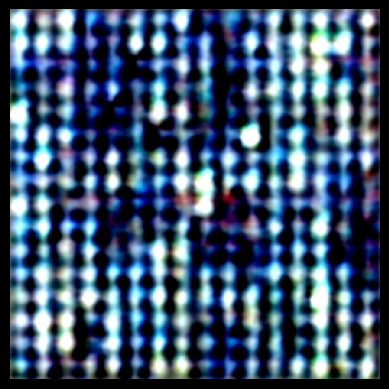

In [15]:
generate_test_sample()

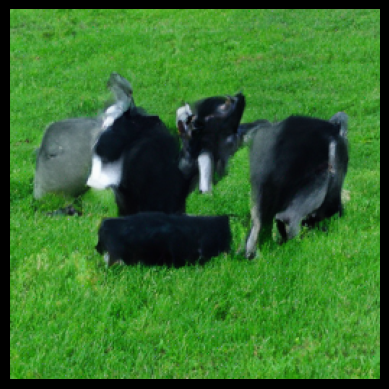

  3%|▎         | 131/4624 [01:05<37:40,  1.99it/s]


KeyboardInterrupt: 

In [16]:
from torch.utils.tensorboard import SummaryWriter

writer = SummaryWriter(log_dir="../../runs/transformer/t-1")
writer_idx = 0

epochs = 1000

for epoch in range(27, epochs):
    num_steps = 0
    loss_sum = 0
    transformer.train()
    for latents, texts in tqdm(train_loader):
        num_steps += 1
        batch_size = latents.shape[0]
        latents = latents.cuda().float()

        latents = patchify_latents(latents)
        latents -= latents_bn_mean
        latents /= latents_bn_std
        # latents = unpatchify_latents(latents)

        img_ids = prepare_latent_ids(latents).to(device)
        latents = pack_latents(latents)

        text_embeds = encode_text_batch(texts)
        embed_mask = torch.randint(0, 100, (batch_size,), device=device) > 5
        embed_mask = embed_mask.float()
        text_embeds = text_embeds * embed_mask[:, None, None]
        txt_ids = prepare_text_ids(text_embeds).to(device)

        timesteps = torch.randint(0, num_train_timesteps, (batch_size,), device=device)
        noise = torch.randn_like(latents)
        sigmas = timesteps / num_train_timesteps
        sigmas = sigmas[:, None, None]
        noisy_latents = latents * (1 - sigmas) + noise * sigmas

        predicted_velocity = transformer(
            hidden_states=noisy_latents,
            encoder_hidden_states=text_embeds,
            timestep=timesteps,
            img_ids=img_ids,
            txt_ids=txt_ids,
        )

        target = noise - latents

        loss = ((target - predicted_velocity) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += float(loss.item())

        if num_steps % 100 == 0:
            generate_test_sample(epoch_number=epoch)
            transformer.train()
            writer.add_scalar("train_loss", loss_sum / num_steps, writer_idx)
            writer_idx += 1
            num_steps = 0
            loss_sum = 0

    torch.save(
        transformer.state_dict(), "../../trained_models/transformer-autosave.pth"
    )

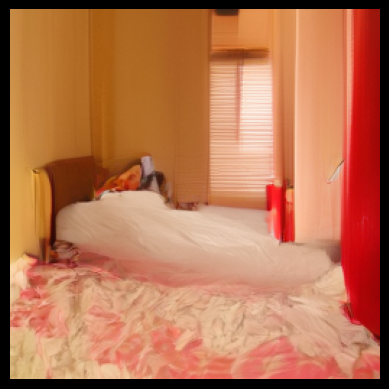

In [37]:
generate_test_sample(prompt="A red car on the bed in the bedroom")

In [ ]:
torch.save(transformer.state_dict(), "../../trained_models/flow_transformer_t-1.pth")